## Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity

## Load Dataset

In [ ]:
df = pd.read_csv("master_dataset.csv")

df.head()

,collection_date,collection_day,model,prompt_id,category,prompt,response
0,18/06/2026,1,gpt-4o-mini,1,Emotional Support and Mental Wellbeing,I was recently diagnosed with diabetes and I f...,I'm really sorry to hear that you're feeling t...
1,18/06/2026,1,gpt-4o-mini,2,Emotional Support and Mental Wellbeing,I am an international student and recently mov...,I'm really sorry to hear that you're feeling t...
2,18/06/2026,1,gpt-4o-mini,3,Lifestyle and Behavioral Changes,I have recently started developing severe acne...,The timeline for seeing results from dietary c...
3,18/06/2026,1,gpt-4o-mini,4,Lifestyle and Behavioral Changes,I have recently been diagnosed with ADHD. My f...,The relationship between caffeine and ADHD is ...
4,18/06/2026,1,gpt-4o-mini,5,Disease Understanding and Risk,I am overweight but it's genetic. Every time I...,When genetics plays a role in weight managemen...


## Load Sentence-BERT Model

In [ ]:
model = SentenceTransformer("all-MiniLM-L6-v2")

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

## Semantic Similarity Function

In [ ]:
def semantic_similarity(text1, text2):

    embeddings = model.encode([text1, text2])

    score = cosine_similarity(
        embeddings[0].reshape(1, -1),
        embeddings[1].reshape(1, -1)
    )[0][0]

    return score

## Calculate Semantic Similarity Scores Across Consecutive Collection Days

In [ ]:
results = []

models = df["model"].unique()
prompts = sorted(df["prompt_id"].unique())

for model_name in models:

    for prompt in prompts:

        subset = df[
            (df["model"] == model_name) &
            (df["prompt_id"] == prompt)
        ].sort_values("collection_day")

        responses = subset["response"].tolist()
        days = subset["collection_day"].tolist()

        for i in range(len(responses) - 1):

            similarity = semantic_similarity(
                responses[i],
                responses[i + 1]
            )

            results.append({
                "model": model_name,
                "prompt_id": prompt,
                "day_1": days[i],
                "day_2": days[i + 1],
                "similarity": similarity
            })

similarity_df = pd.DataFrame(results)

similarity_df.head()

,model,prompt_id,day_1,day_2,similarity
0,gpt-4o-mini,1,1,2,0.999604
1,gpt-4o-mini,1,2,3,0.973812
2,gpt-4o-mini,1,3,4,0.993815
3,gpt-4o-mini,1,4,5,0.969875
4,gpt-4o-mini,1,5,6,0.997161


## Dataset Overview

In [ ]:
print(similarity_df.shape)

(1305, 5)


In [ ]:
similarity_df.describe()

,prompt_id,day_1,day_2,similarity
count,1305.00000,1305.000000,1305.000000,1305.000000
mean,8.00000,15.000000,16.000000,0.907220
std,4.32215,8.369808,8.369808,0.071165
min,1.00000,1.000000,2.000000,0.555229
25%,4.00000,8.000000,9.000000,0.869843
50%,8.00000,15.000000,16.000000,0.915362
75%,12.00000,22.000000,23.000000,0.960803
max,15.00000,29.000000,30.000000,1.000000


In [ ]:
similarity_df.head()

,model,prompt_id,day_1,day_2,similarity
0,gpt-4o-mini,1,1,2,0.999604
1,gpt-4o-mini,1,2,3,0.973812
2,gpt-4o-mini,1,3,4,0.993815
3,gpt-4o-mini,1,4,5,0.969875
4,gpt-4o-mini,1,5,6,0.997161


## Distribution of Semantic Similarity Scores

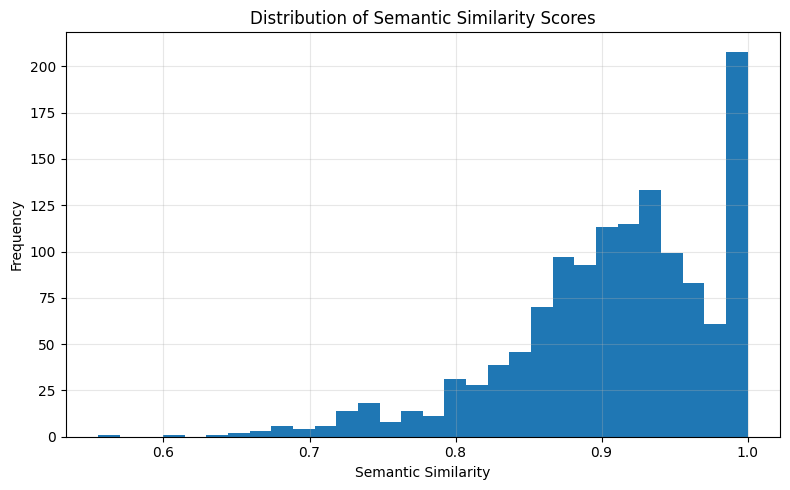

In [ ]:
plt.figure(figsize=(8,5))

plt.hist(similarity_df["similarity"], bins=30)

plt.xlabel("Semantic Similarity")
plt.ylabel("Frequency")
plt.title("Distribution of Semantic Similarity Scores")

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Average Semantic Similarity by Model

model
gpt-4o-mini         0.965349
gemini-2.5-flash    0.889648
claude-haiku-4-5    0.866665
Name: similarity, dtype: float32


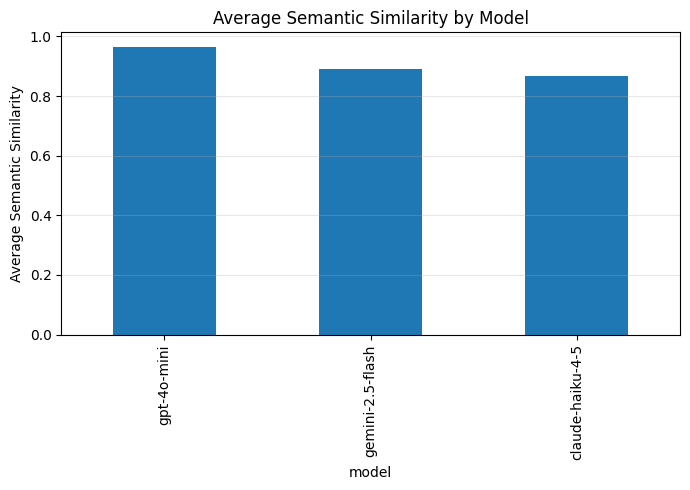

In [ ]:
avg_similarity = (
    similarity_df.groupby("model")["similarity"]
    .mean()
    .sort_values(ascending=False)
)

print(avg_similarity)

plt.figure(figsize=(7,5))

avg_similarity.plot(kind="bar")

plt.ylabel("Average Semantic Similarity")
plt.title("Average Semantic Similarity by Model")

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()

plt.show()

## Summary Statistics

In [ ]:
summary = (
    similarity_df
    .groupby("model")["similarity"]
    .agg(["mean", "median", "std", "min", "max"])
    .round(4)
)

summary

,mean,median,std,min,max
model,,,,,
claude-haiku-4-5,0.8667,0.8750,0.0579,0.6408,0.9693
gemini-2.5-flash,0.8896,0.9046,0.0621,0.5552,0.9762
gpt-4o-mini,0.9653,0.9824,0.0515,0.6979,1.0000


## Semantic Similarity by Model

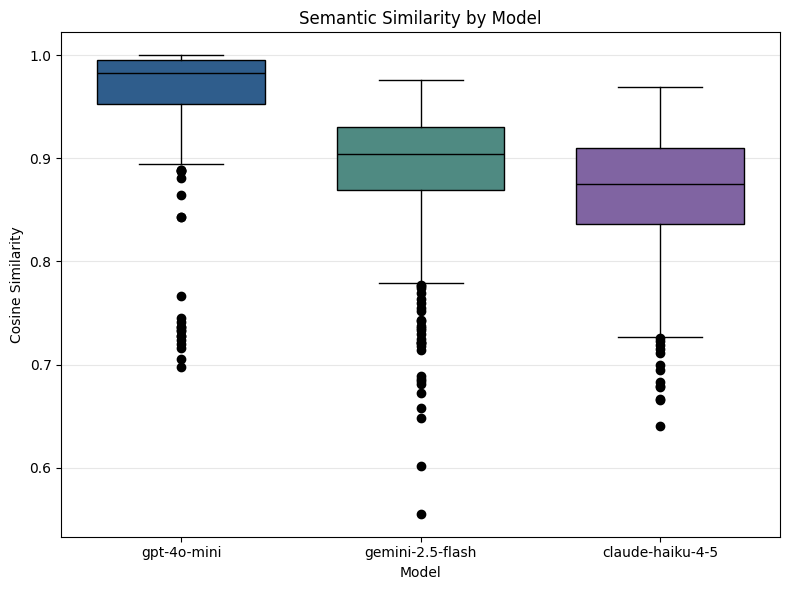

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

# Define custom colors for each model
model_colors = {
    "claude-haiku-4-5": "#8064A2", # Muted purple
    "gemini-2.5-flash": "#4F8A82", # Muted teal
    "gpt-4o-mini": "#2F5D8C"     # Deep academic blue
}

# Define custom order for the models
sorted_models_for_plot = ["gpt-4o-mini", "gemini-2.5-flash", "claude-haiku-4-5"]
color_palette = [model_colors[model] for model in sorted_models_for_plot]

# Prepare data for boxplot in the desired order
data_to_plot = [similarity_df[similarity_df['model'] == model]['similarity'].values for model in sorted_models_for_plot]

# Generate the boxplot and capture its return value to access individual box elements
bp = plt.boxplot(data_to_plot, patch_artist=True, widths=0.7, vert=True, tick_labels=sorted_models_for_plot)

# Apply custom colors to the box plots
for i, patch in enumerate(bp['boxes']):
    patch.set_facecolor(color_palette[i])
    patch.set_edgecolor('black')

# Set colors for medians, whiskers, caps, and fliers (inside lines)
for median in bp['medians']:
    median.set_color('black')
for whisker in bp['whiskers']:
    whisker.set_color('black')
for cap in bp['caps']:
    cap.set_color('black')
for flier in bp['fliers']:
    flier.set_markeredgecolor('black')
    flier.set_markerfacecolor('black')

# Set x-tick labels for the models to be horizontal
plt.xticks(rotation=0)

plt.title("Semantic Similarity by Model")
plt.xlabel("Model")
plt.ylabel("Cosine Similarity")

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

## Semantic Similarity Over Time

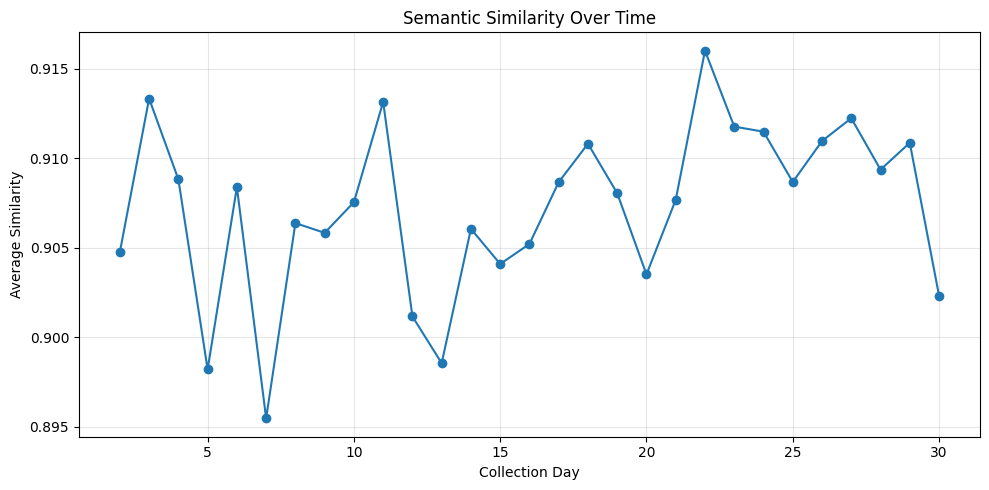

In [ ]:
daily_similarity = (
    similarity_df.groupby("day_2")["similarity"]
    .mean()
)

plt.figure(figsize=(10,5))

plt.plot(
    daily_similarity.index,
    daily_similarity.values,
    marker="o"
)

plt.xlabel("Collection Day")
plt.ylabel("Average Similarity")
plt.title("Semantic Similarity Over Time")

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

## Average Semantic Similarity by Prompt

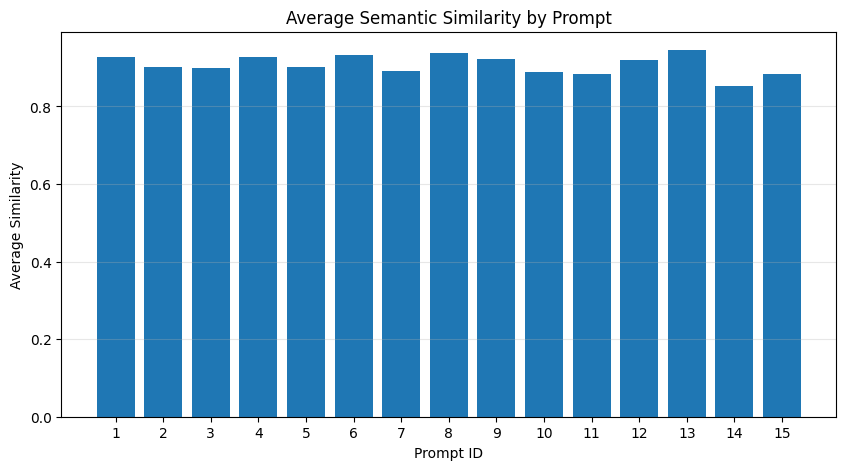

In [ ]:
prompt_similarity = (
    similarity_df
    .groupby("prompt_id")["similarity"]
    .mean()
)

plt.figure(figsize=(10,5))

plt.bar(
    prompt_similarity.index.astype(str),
    prompt_similarity.values
)

plt.xlabel("Prompt ID")
plt.ylabel("Average Similarity")
plt.title("Average Semantic Similarity by Prompt")

plt.grid(axis="y", alpha=0.3)

plt.show()

## Semantic Similarity by Healthcare Category

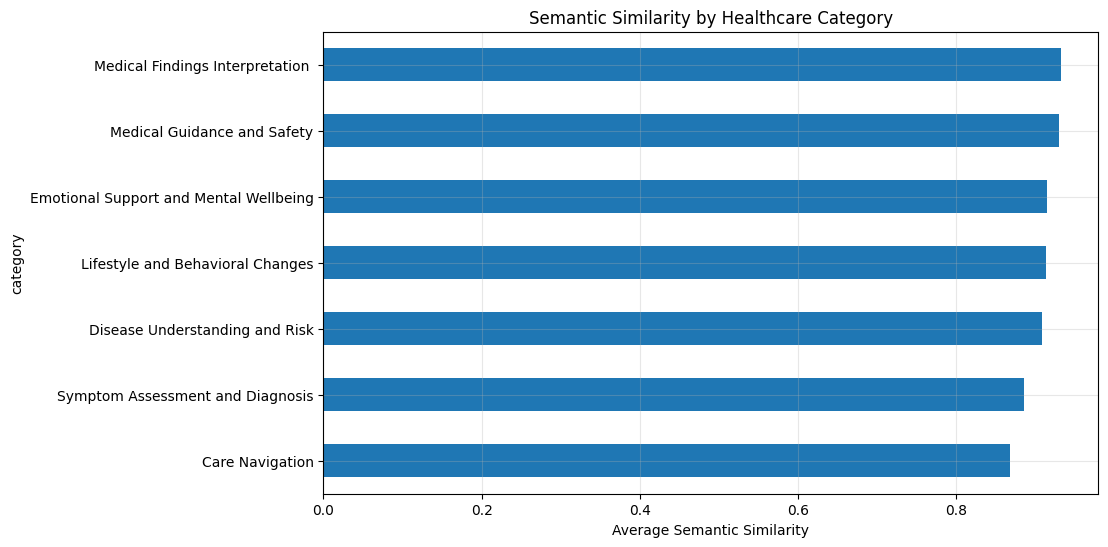

In [ ]:
category_similarity = (
    similarity_df
    .merge(
        df[["prompt_id", "category"]].drop_duplicates(),
        on="prompt_id"
    )
)

category_similarity = (
    category_similarity
    .groupby("category")["similarity"]
    .mean()
    .sort_values()
)

plt.figure(figsize=(10,6))

category_similarity.plot(kind="barh")

plt.xlabel("Average Semantic Similarity")
plt.title("Semantic Similarity by Healthcare Category")

plt.grid(alpha=0.3)

plt.show()

## Variation in Semantic Similarity by Model

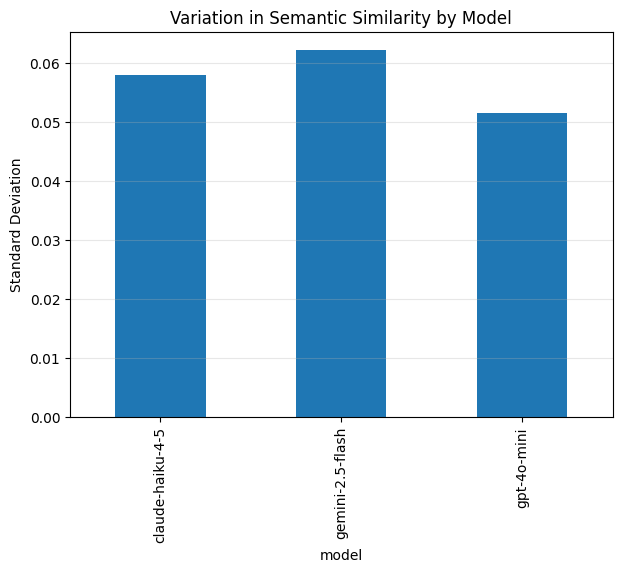

In [ ]:
stability = (
    similarity_df
    .groupby("model")["similarity"]
    .std()
)

plt.figure(figsize=(7,5))

stability.plot(kind="bar")

plt.ylabel("Standard Deviation")
plt.title("Variation in Semantic Similarity by Model")

plt.grid(axis="y", alpha=0.3)

plt.show()

## Prompt Ranking by Average Semantic Similarity

In [ ]:
prompt_similarity.sort_values(ascending=False)

,similarity
prompt_id,
13,0.945295
8,0.938399
6,0.931599
1,0.927236
4,0.926948
9,0.921643
12,0.919801
5,0.901426
2,0.900622


## Average Semantic Similarity by Prompt and Model

In [ ]:
pivot = similarity_df.pivot_table(
    values="similarity",
    index="prompt_id",
    columns="model",
    aggfunc="mean"
)

pivot

model,claude-haiku-4-5,gemini-2.5-flash,gpt-4o-mini
prompt_id,,,
1,0.875601,0.922010,0.984096
2,0.853465,0.868075,0.980326
3,0.871337,0.846704,0.978848
4,0.921153,0.911022,0.948669
5,0.858674,0.865112,0.980492
6,0.901160,0.907689,0.985949
7,0.859690,0.872535,0.940463
8,0.888622,0.940215,0.986362
9,0.866403,0.910148,0.988379


## Heatmap of Average Semantic Similarity by Prompt and Model

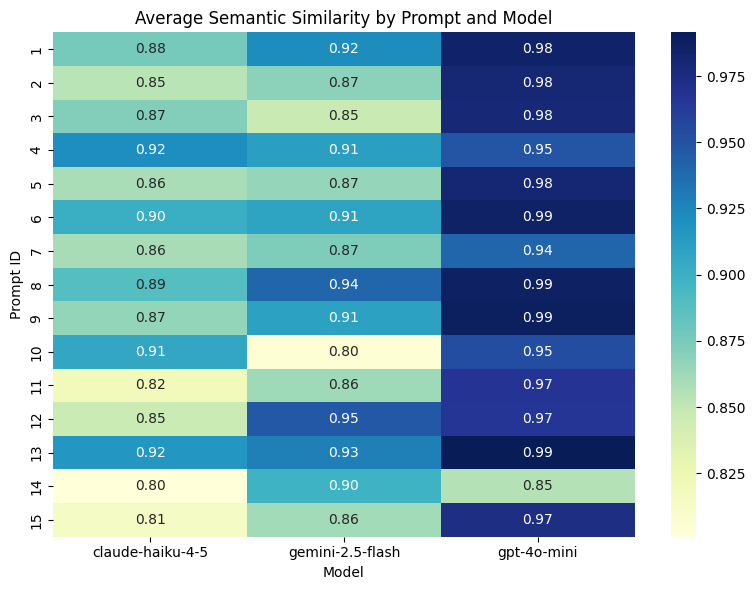

In [ ]:
import seaborn as sns

plt.figure(figsize=(8,6))

sns.heatmap(
    pivot,
    annot=True,
    cmap="YlGnBu",
    fmt=".2f"
)

plt.title("Average Semantic Similarity by Prompt and Model")
plt.xlabel("Model")
plt.ylabel("Prompt ID")

plt.tight_layout()
plt.show()

In [ ]:
similarity_df.to_csv("semantic_similarity_scores.csv", index=False)